# Step 5: Estimate Coastal Advection (u, v)

## Why this matters

The heat equation used by the PINN is:

$$
\frac{\partial T}{\partial t} + u\frac{\partial T}{\partial x} + v\frac{\partial T}{\partial y}
= \alpha \nabla^2 T
$$

- **u, v** = how currents carry heat (advection)
- **α** = how heat spreads (diffusion)

Previously we hard-coded `u = 0`, `v = 0` (diffusion only).
We do **not** have an ocean-current product in this repo, so we **estimate** a constant (u, v) from the five SST sites themselves.

## Intuition (plain English)

If water is warmer to the west and temperatures are rising at a site, a current flowing from west → east can help explain that warming.

We:
1. Measure how temperature changes in time at each reef (`∂T/∂t`)
2. Measure spatial temperature slopes between reefs (`∂T/∂lon`, `∂T/∂lat`)
3. Solve for **u, v** that best match the heat equation (least squares)

Result is saved to `advection.pkl` and loaded automatically by training + the forecaster.

## Import libraries

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prepare_data import load_all_locations
from estimate_advection import estimate_advection, estimate_and_save

print("Libraries loaded")

Libraries loaded


## Load the same real multi-site temperatures

In [2]:
df = load_all_locations()
print(f"Loaded {len(df)} rows across {df['location'].nunique()} locations")
print(df.groupby('location')[['latitude','longitude']].first())

Loaded 20095 rows across 5 locations
            latitude  longitude
location                       
hikkaduwa      6.125     80.075
kalpitiya      8.375     79.725
passikudha     7.925     81.575
south_east     6.175     81.475
trinco         8.725     81.175


## Run the advection fit

This may take a few seconds — it builds one equation per site per day.

In [3]:
result = estimate_and_save()

print("\n" + "=" * 60)
print("ADVECTION ESTIMATE")
print("=" * 60)
print(f"  u_adv (norm) : {result['u_adv']:.6f}")
print(f"  v_adv (norm) : {result['v_adv']:.6f}")
print(f"  alpha        : {result['alpha']:.4f}")
print(f"  method       : {result['method']}")
print(f"  # equations  : {result['n_equations']}")
print("=" * 60)

Advection estimate:
  u_adv: 0.025866422465489782
  v_adv: 0.0036664258136414438
  alpha: 0.01
  method: sst_gradient_lstsq
  n_equations: 20090
Saved -> d:\corals\model\advection.pkl

ADVECTION ESTIMATE
  u_adv (norm) : 0.025866
  v_adv (norm) : 0.003666
  alpha        : 0.0100
  method       : sst_gradient_lstsq
  # equations  : 20090


## How to read these numbers

| Field | Meaning |
|-------|--------|
| `u_adv` | East–west heat transport in **normalised** PINN coordinates |
| `v_adv` | North–south heat transport (normalised) |
| `u_phys_deg_per_day` | Same idea in physical lon-degrees / day |
| `alpha` | Diffusion weight used in the PDE residual |

Values near zero mean advection is weak compared to local heating/cooling.
Non-zero values are still small — that is expected for daily satellite SST.

In [4]:
with open("advection.pkl", "rb") as f:
    adv = pickle.load(f)

pd.Series(adv).to_frame("value")

,value
u_adv,0.025866
v_adv,0.003666
u_phys_deg_per_day,0.013982
v_phys_deg_per_day,0.00141
alpha,0.01
alpha_phys,0.05
n_equations,20090
lstsq_rank,2
residual_norm,28.47788
method,sst_gradient_lstsq


## Quick map of the five sites

Helps you see the spatial layout the gradient fit is using.

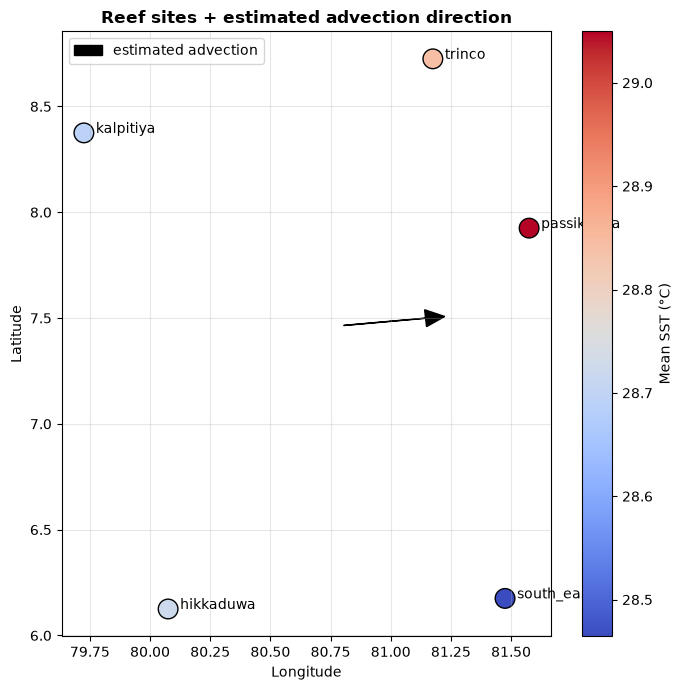

In [5]:
sites = df.groupby("location")[["latitude", "longitude", "analysed_sst"]].mean()

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(
    sites["longitude"], sites["latitude"],
    c=sites["analysed_sst"], s=200, cmap="coolwarm", edgecolors="k"
)
for name, row in sites.iterrows():
    ax.annotate(name, (row["longitude"] + 0.05, row["latitude"]), fontsize=10)

# Draw estimated advection as an arrow from the map centre
cx, cy = sites["longitude"].mean(), sites["latitude"].mean()
scale = 30  # visual only
ax.arrow(
    cx, cy,
    adv["u_phys_deg_per_day"] * scale,
    adv["v_phys_deg_per_day"] * scale,
    head_width=0.08, head_length=0.08, fc="black", ec="black", length_includes_head=True,
    label="estimated advection"
)

plt.colorbar(sc, ax=ax, label="Mean SST (°C)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Reef sites + estimated advection direction", fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Summary

`advection.pkl` is ready.

- `02_pinn_model.ipynb` will load it and use **u, v** inside the PDE loss
- `forecaster.py` will use the same values for physics residuals at inference

**Next:** re-train the PINN, then open `06_evaluation.ipynb`.